In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [6]:
df = pd.read_csv("./train.csv")

In [3]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
df.shape

(1460, 81)

In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
df.describe() # Only the numerical columns

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
df.describe(include="all") # All the columns numerical and categorical

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


## 1. Outlier detection for numerical columns

### a) Using Boxplot

In [9]:
numerical_col = ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 
                 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1','BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                 '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 
                 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 
                 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF','EnclosedPorch', 
                 '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'
                 ]

df_num = df[numerical_col].copy()

df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


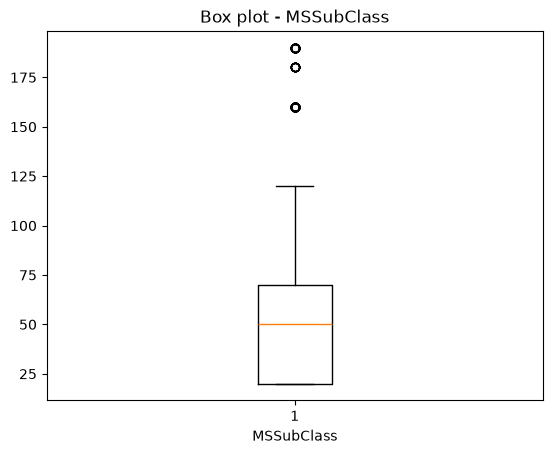

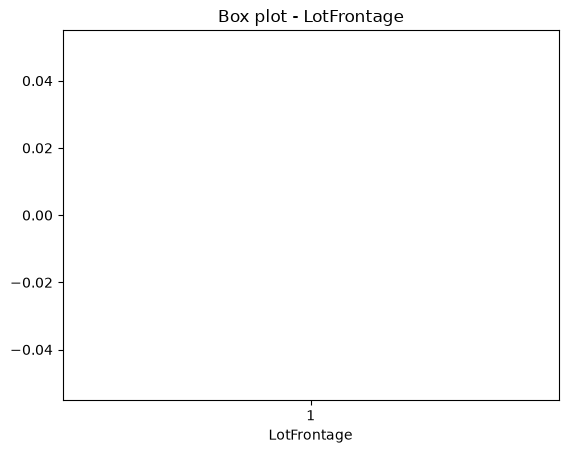

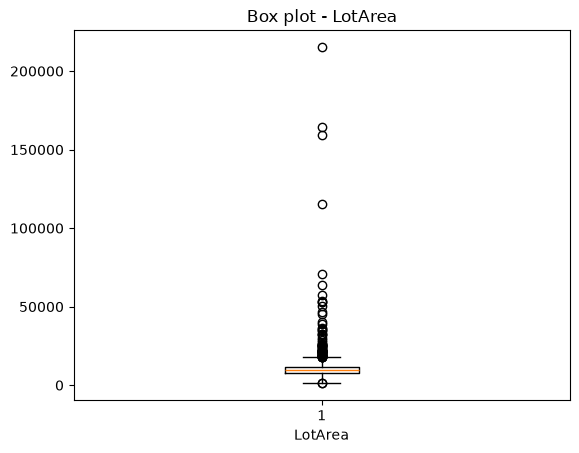

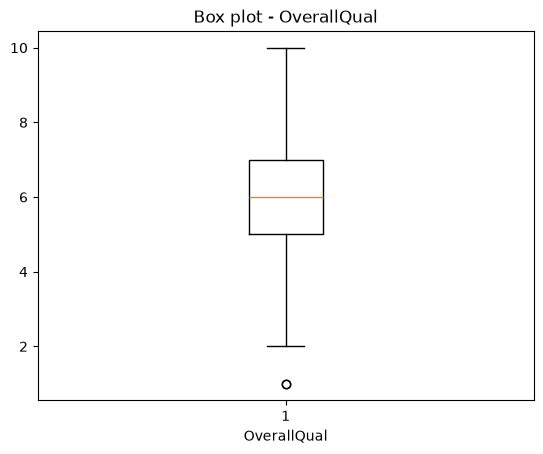

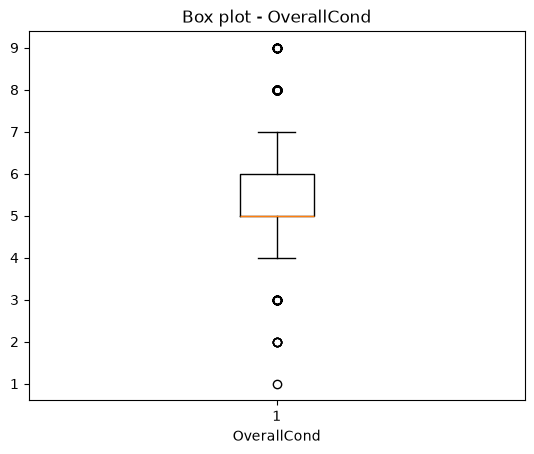

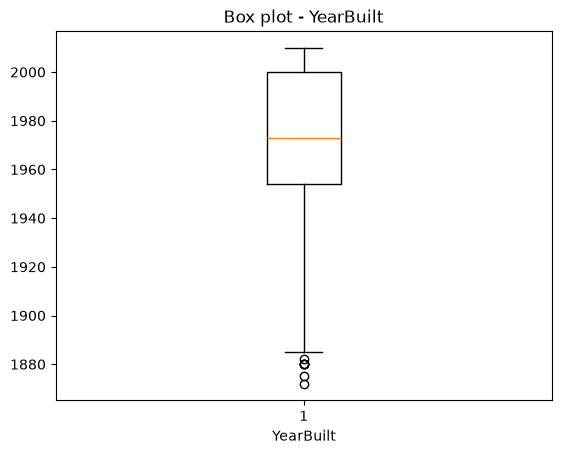

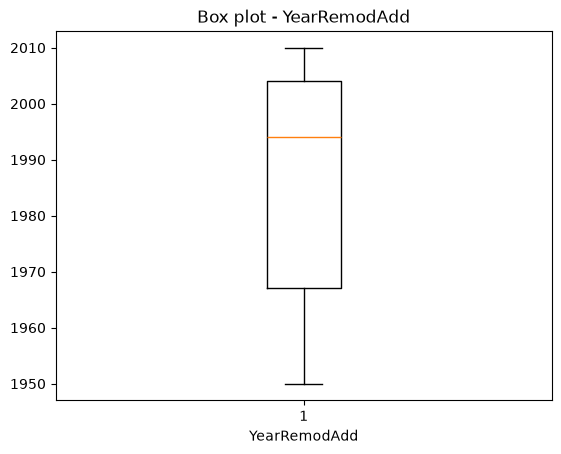

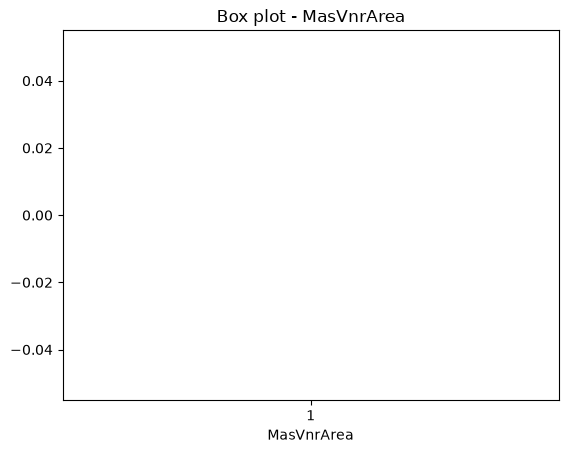

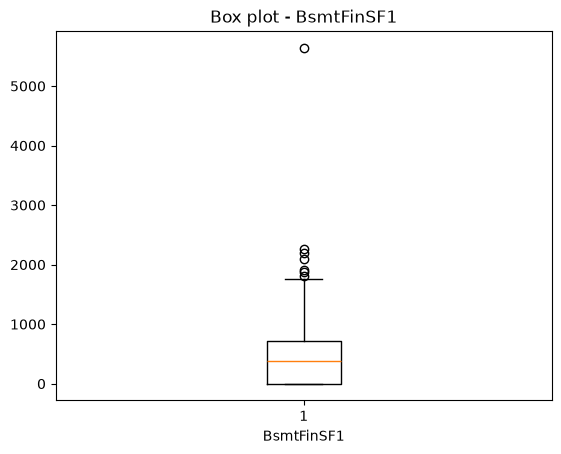

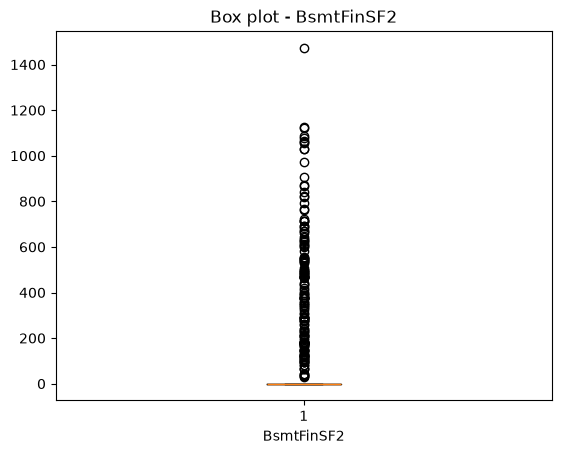

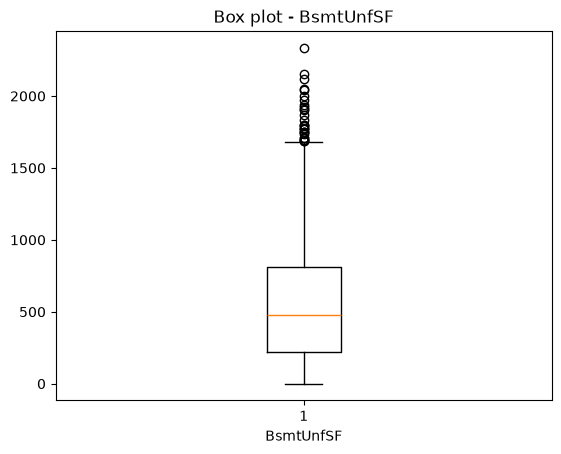

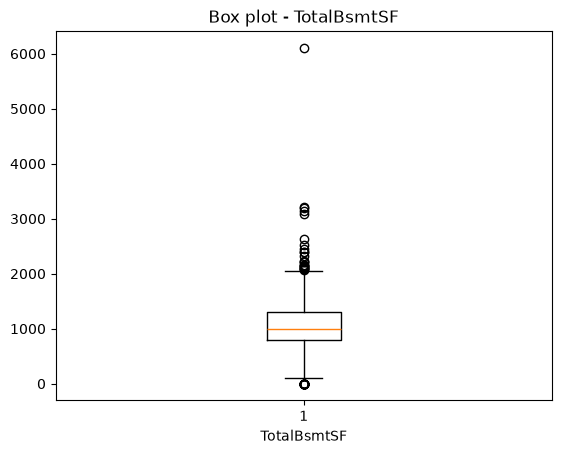

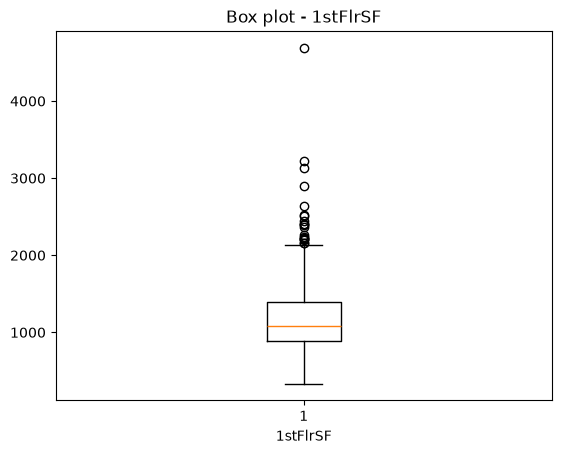

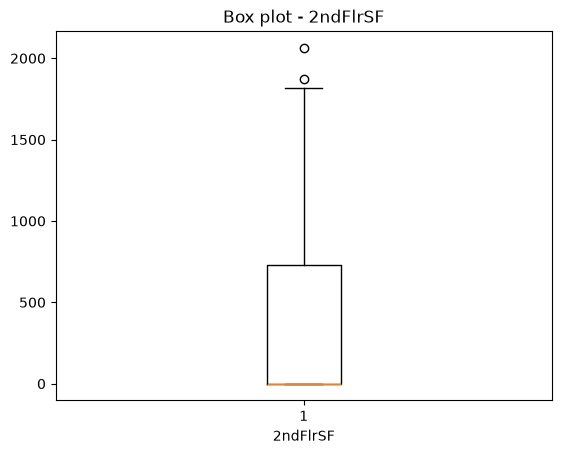

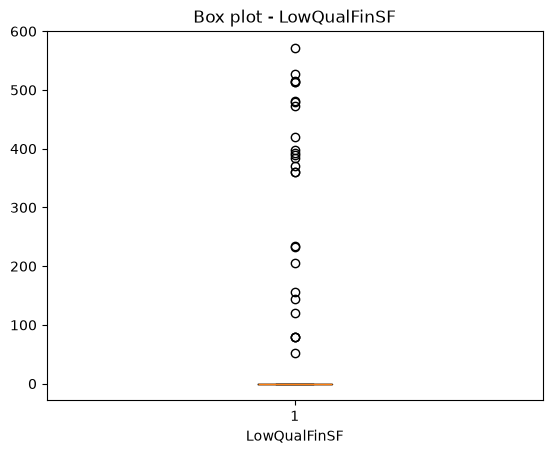

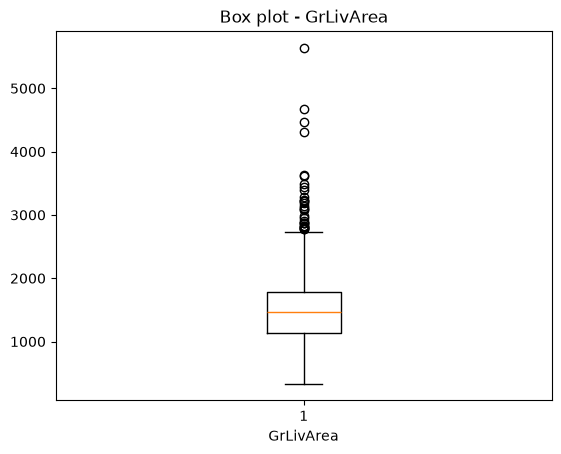

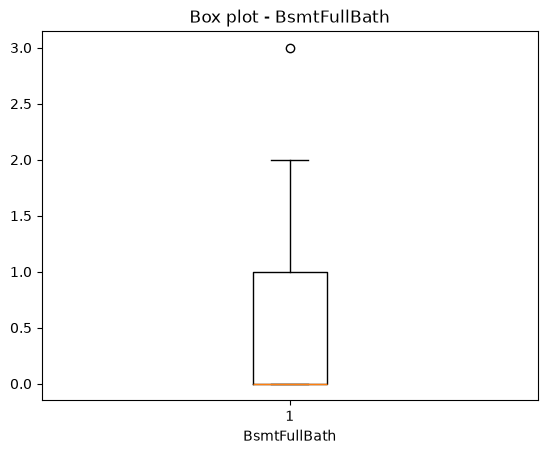

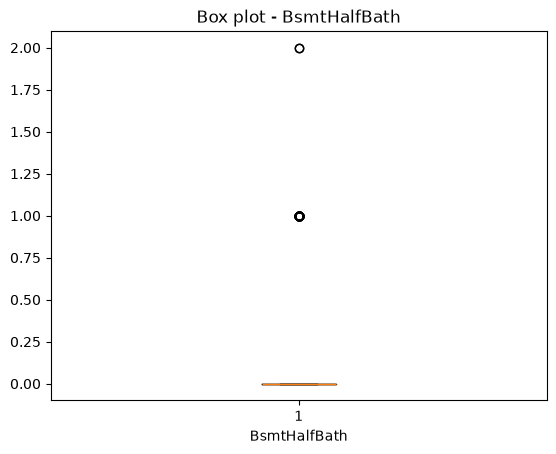

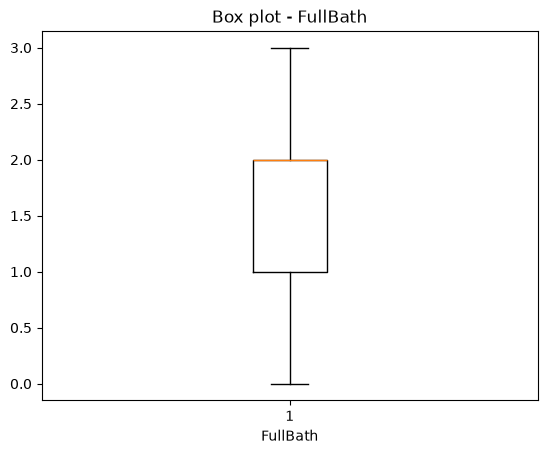

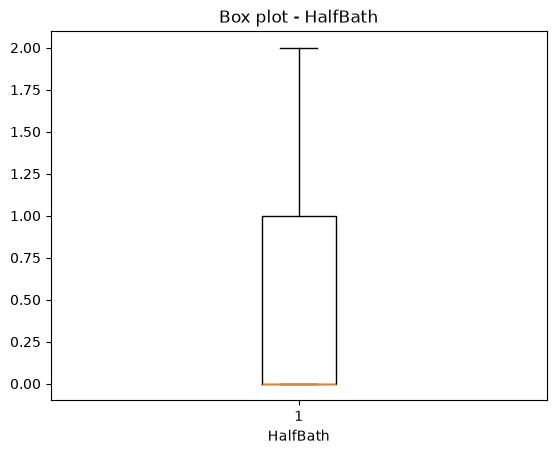

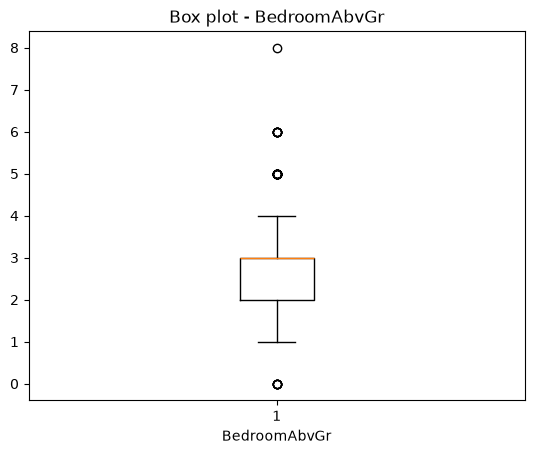

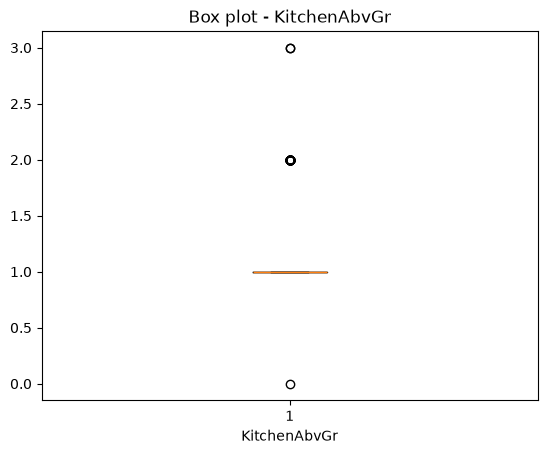

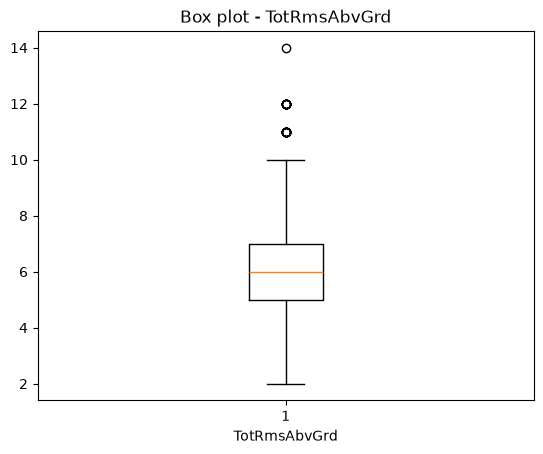

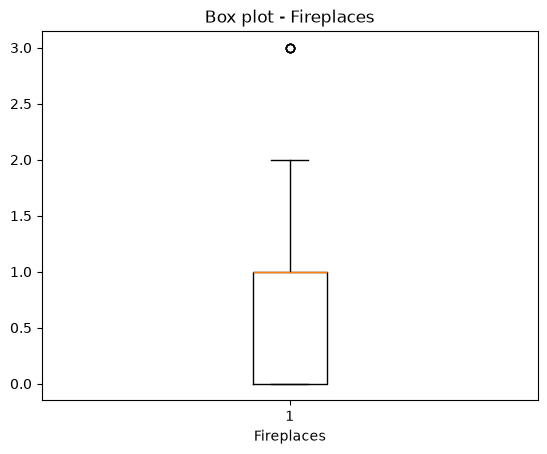

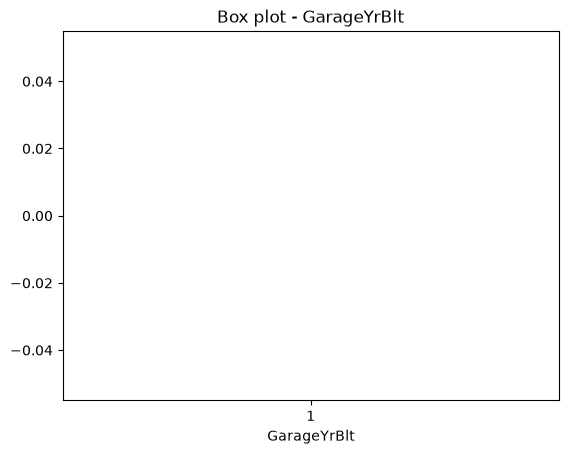

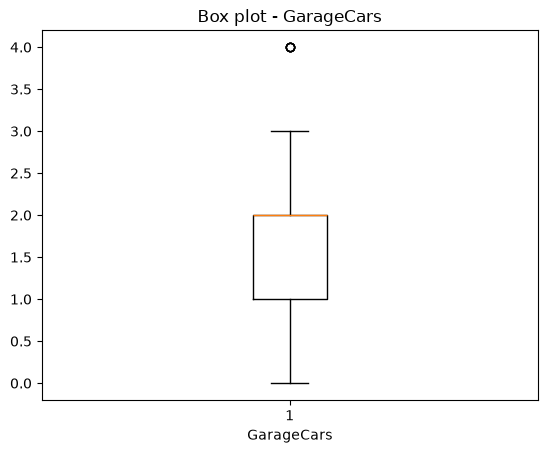

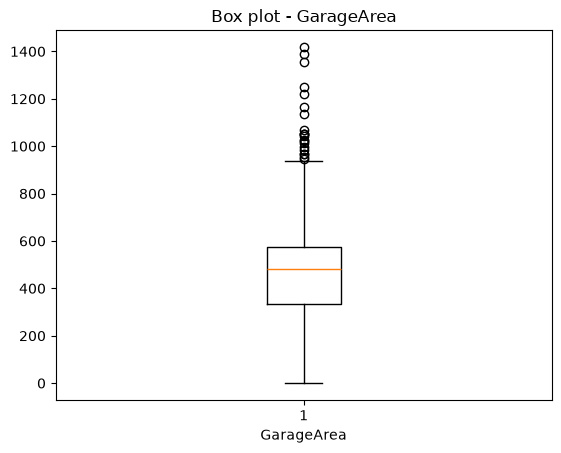

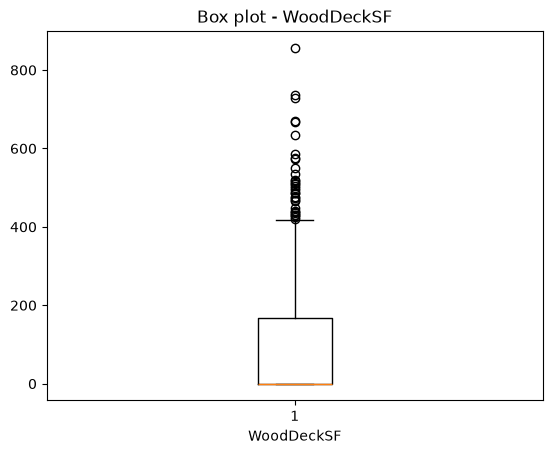

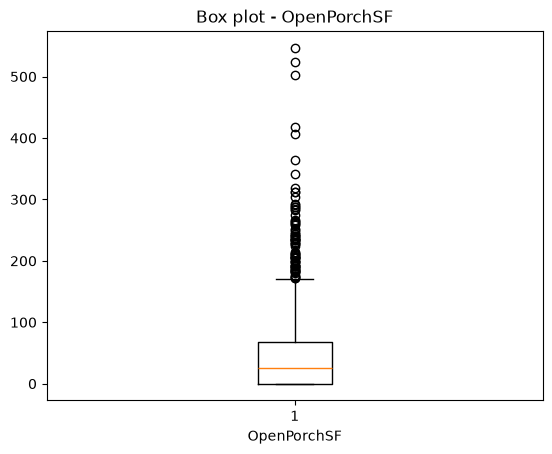

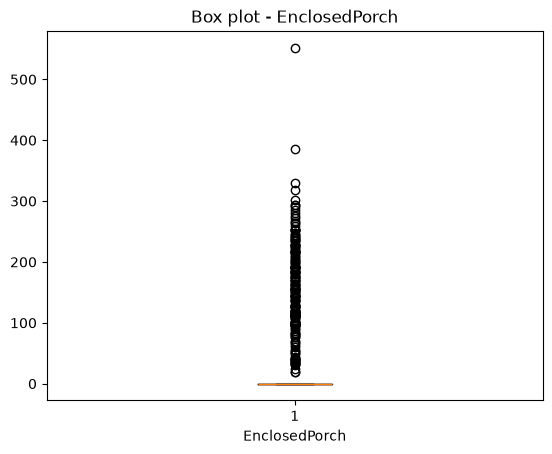

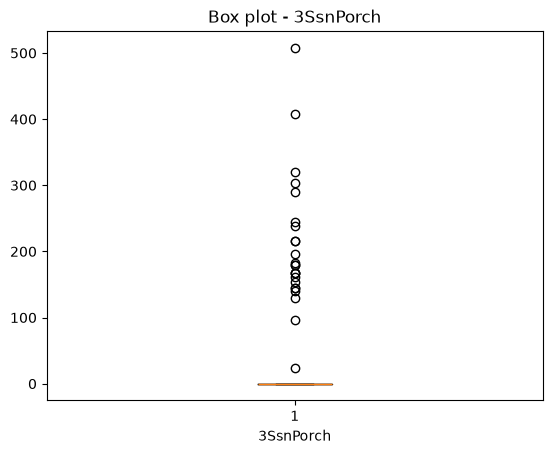

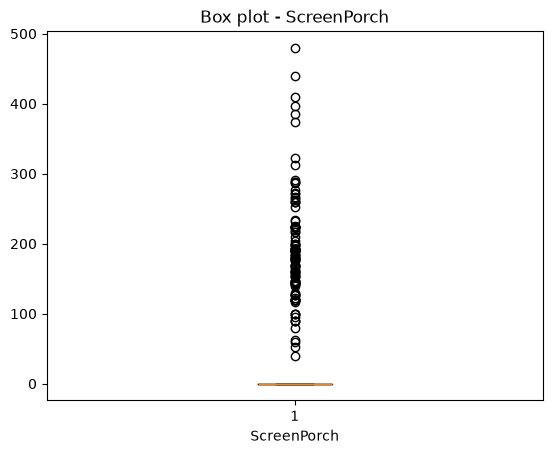

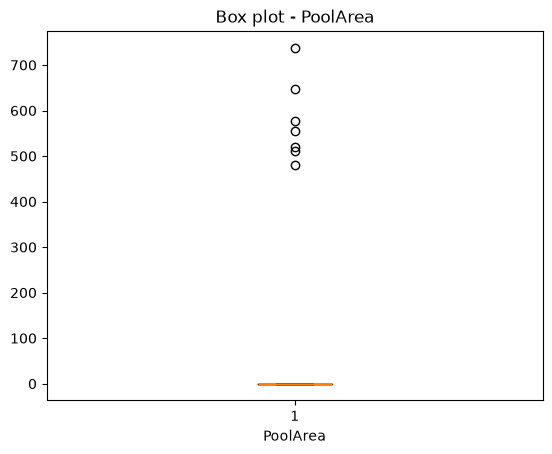

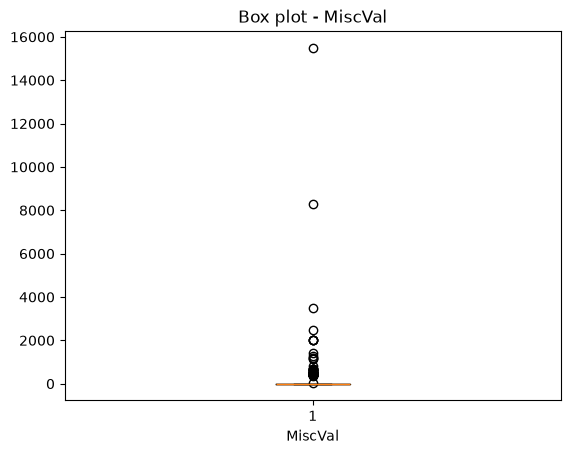

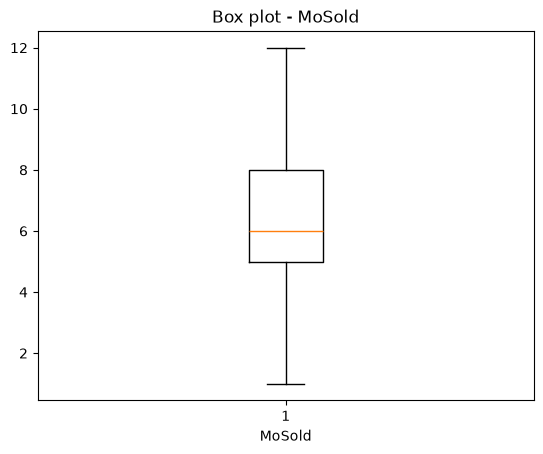

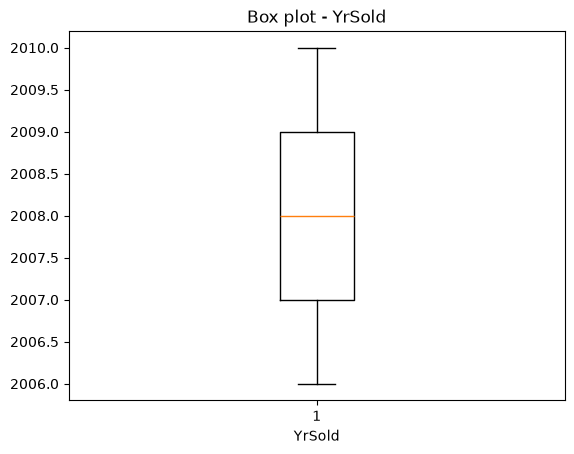

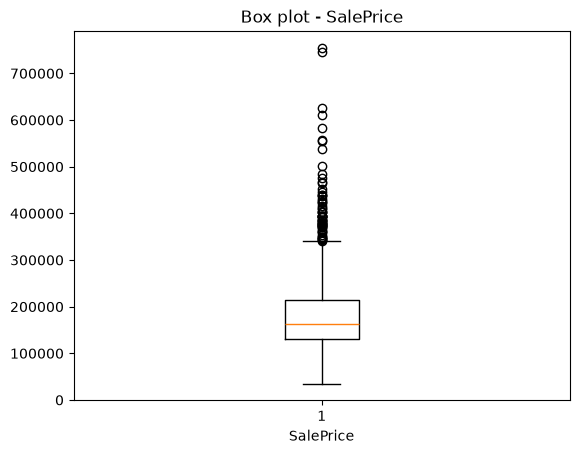

In [10]:
for col in numerical_col:
    plt.boxplot(df_num[col])
    plt.title(f"Box plot - {col}")
    plt.xlabel(col)
    plt.show()

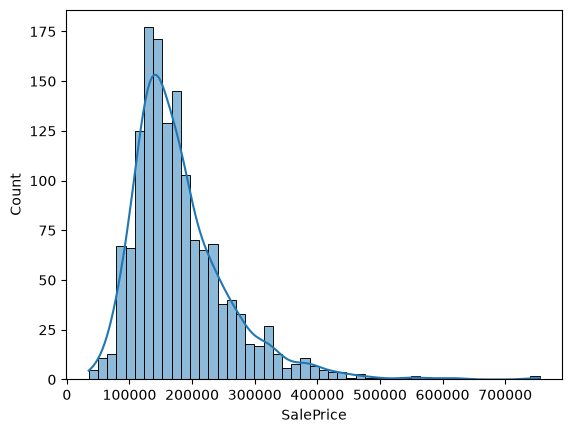

In [11]:
sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.show()

### b) Using IQR 

In [12]:
iqr_counts = {}

for col in numerical_col:
    s = df_num[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    iqr_counts[col] = int(((df_num[col] < lower) | (df_num[col] > upper)).sum())
    
pd.DataFrame({'IQR_outliers': iqr_counts})

,IQR_outliers
MSSubClass,103
LotFrontage,88
LotArea,69
OverallQual,2
OverallCond,125
YearBuilt,7
YearRemodAdd,0
MasVnrArea,96
BsmtFinSF1,7
BsmtFinSF2,167


### c) Z score 

In [13]:
def zscore_series(s: pd.Series):
    s = s.dropna()
    return (s - s.mean()) / s.std(ddof=0)

z_counts = {}

for col in numerical_col: 
    z = zscore_series(df_num[col])
    z_counts[col] = int((np.abs(z) > 3).sum())
    
pd.DataFrame({ "Z Score outliers": z_counts})

,Z Score outliers
MSSubClass,30
LotFrontage,12
LotArea,13
OverallQual,2
OverallCond,28
YearBuilt,6
YearRemodAdd,0
MasVnrArea,32
BsmtFinSF1,6
BsmtFinSF2,50


## Choosing IQR over Z score because the data is skewed and the data is not normally distributed 

In [99]:
dfcopy = df.copy()

In [100]:
dfcopy.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Trimming the below columns to remove the outliers because they have very less outliers based on IQR findings because the dataset is big enough to handle trim for value below 10 outliers

- OverallQual
- YearBuilt
- BsmtFinSF1
- 2ndFlrSF
- BsmtFullBath
- Fireplaces
- GarageCars
- PoolArea

In [27]:
# Calculate Q1, Q3 and IQR
Q1 = dfcopy['OverallQual'].quantile(0.25)
Q3 = dfcopy['OverallQual'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["OverallQual"] >= lower_limit) & (dfcopy["OverallQual"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: 2.0
Upper Limit: 10.0
Original Shape:  (1460, 81)
After trimming:  (1458, 81)


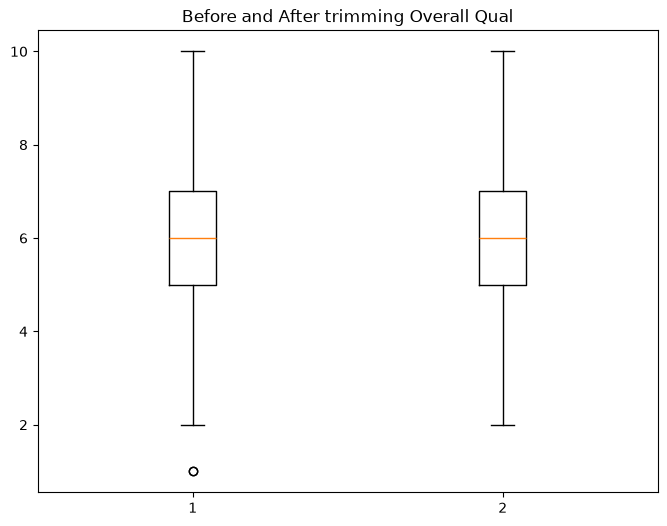

In [28]:
plt.figure(figsize=(8,6))
plt.boxplot([dfcopy["OverallQual"].dropna(), df_trimmed["OverallQual"].dropna()], 
            label=["Before", "After"])
plt.title("Before and After trimming Overall Qual")
plt.show()

In [29]:
Q1 = dfcopy['YearBuilt'].quantile(0.25)
Q3 = dfcopy['YearBuilt'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["YearBuilt"] >= lower_limit) & (dfcopy["YearBuilt"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: 1885.0
Upper Limit: 2069.0
Original Shape:  (1460, 81)
After trimming:  (1453, 81)


In [30]:
Q1 = dfcopy['BsmtFinSF1'].quantile(0.25)
Q3 = dfcopy['BsmtFinSF1'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["BsmtFinSF1"] >= lower_limit) & (dfcopy["BsmtFinSF1"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: -1068.375
Upper Limit: 1780.625
Original Shape:  (1460, 81)
After trimming:  (1453, 81)


In [31]:
Q1 = dfcopy['2ndFlrSF'].quantile(0.25)
Q3 = dfcopy['2ndFlrSF'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["2ndFlrSF"] >= lower_limit) & (dfcopy["2ndFlrSF"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: -1092.0
Upper Limit: 1820.0
Original Shape:  (1460, 81)
After trimming:  (1458, 81)


In [32]:
Q1 = dfcopy['BsmtFullBath'].quantile(0.25)
Q3 = dfcopy['BsmtFullBath'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["BsmtFullBath"] >= lower_limit) & (dfcopy["BsmtFullBath"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: -1.5
Upper Limit: 2.5
Original Shape:  (1460, 81)
After trimming:  (1459, 81)


In [33]:
Q1 = dfcopy['Fireplaces'].quantile(0.25)
Q3 = dfcopy['Fireplaces'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["Fireplaces"] >= lower_limit) & (dfcopy["Fireplaces"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: -1.5
Upper Limit: 2.5
Original Shape:  (1460, 81)
After trimming:  (1455, 81)


In [34]:
Q1 = dfcopy['GarageCars'].quantile(0.25)
Q3 = dfcopy['GarageCars'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["GarageCars"] >= lower_limit) & (dfcopy["GarageCars"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: -0.5
Upper Limit: 3.5
Original Shape:  (1460, 81)
After trimming:  (1455, 81)


In [35]:
Q1 = dfcopy['PoolArea'].quantile(0.25)
Q3 = dfcopy['PoolArea'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

df_trimmed = dfcopy[(dfcopy["PoolArea"] >= lower_limit) & (dfcopy["PoolArea"] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After trimming: ", df_trimmed.shape)

Lower Limit: 0.0
Upper Limit: 0.0
Original Shape:  (1460, 81)
After trimming:  (1453, 81)


### Rest of the columns cant be trimmed due to high number of outliers so capping mehod is used on this outliers

- MSSubClass
- LotFrontage
- LotArea
- OverallCond
- MasVnrArea
- BsmtFinSF2
- BsmtUnfSF
- TotalBsmtSF
- 1stFlrSF
- LowQualFinSF
- GrLivArea
- BsmtFullBath
- BsmtHalfBath
- HalfBath
- BedroomAbvGr
- KitchenAbvGr
- TotRmsAbvGrd
- WoodDeckSF
- OpenPorchSF
- EnclosedPorch
- 3SsnPorch
- ScreenPorch
- SalePrice

In [22]:
Q1 = dfcopy["MSSubClass"].quantile(0.25)
Q3 = dfcopy["MSSubClass"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["MSSubClass"] = np.where(
    df_capped["MSSubClass"] > upper_limit, upper_limit,
    np.where(df_capped["MSSubClass"] < lower_limit, lower_limit, df_capped["MSSubClass"])
)

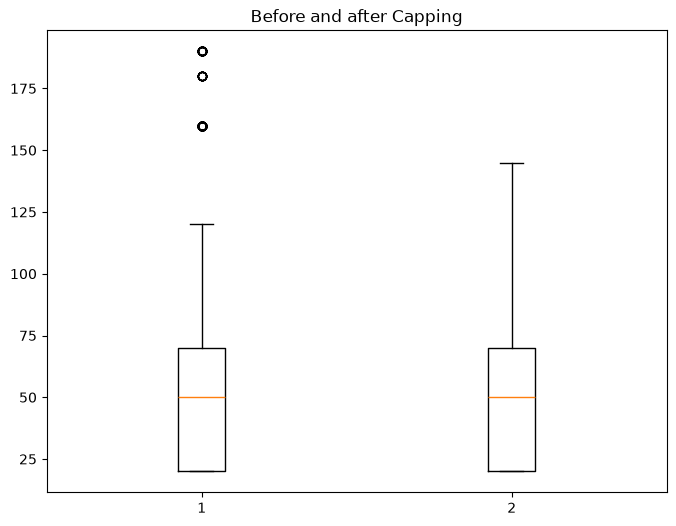

In [23]:
plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["MSSubClass"].dropna(), df_capped["MSSubClass"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

In [52]:
Q1 = dfcopy["LotArea"].quantile(0.25)
Q3 = dfcopy["LotArea"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["LotArea"] = np.where(
    df_capped["LotArea"] > upper_limit, upper_limit,
    np.where(df_capped["LotArea"] < lower_limit, lower_limit, df_capped["LotArea"])
)

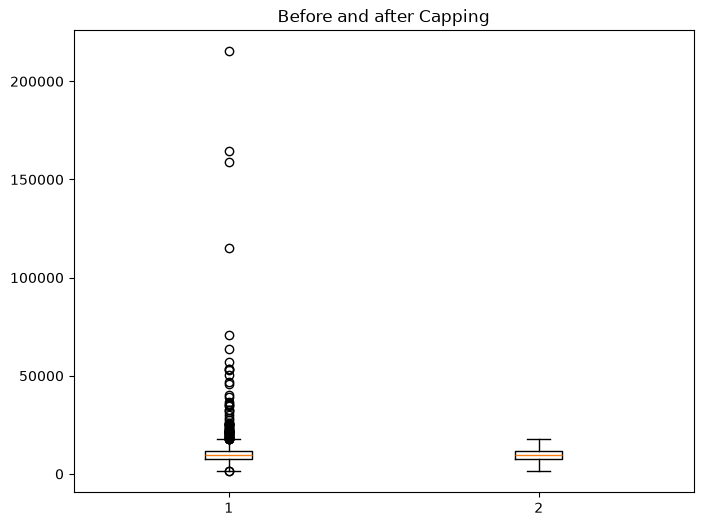

In [54]:
plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["LotArea"].dropna(), df_capped["LotArea"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

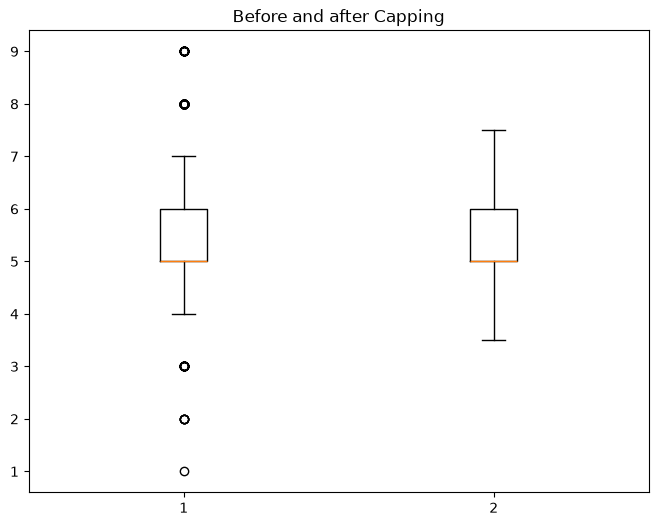

In [55]:
Q1 = dfcopy["OverallCond"].quantile(0.25)
Q3 = dfcopy["OverallCond"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["OverallCond"] = np.where(
    df_capped["OverallCond"] > upper_limit, upper_limit,
    np.where(df_capped["OverallCond"] < lower_limit, lower_limit, df_capped["OverallCond"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["OverallCond"].dropna(), df_capped["OverallCond"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

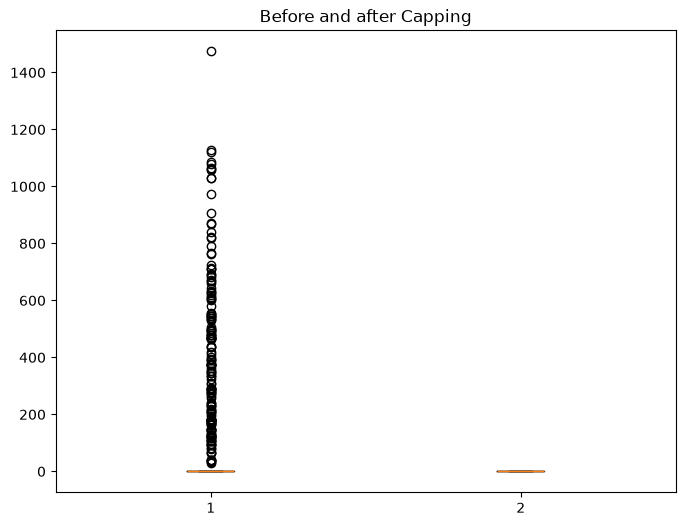

In [57]:
Q1 = dfcopy["BsmtFinSF2"].quantile(0.25)
Q3 = dfcopy["BsmtFinSF2"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["BsmtFinSF2"] = np.where(
    df_capped["BsmtFinSF2"] > upper_limit, upper_limit,
    np.where(df_capped["BsmtFinSF2"] < lower_limit, lower_limit, df_capped["BsmtFinSF2"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["BsmtFinSF2"].dropna(), df_capped["BsmtFinSF2"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

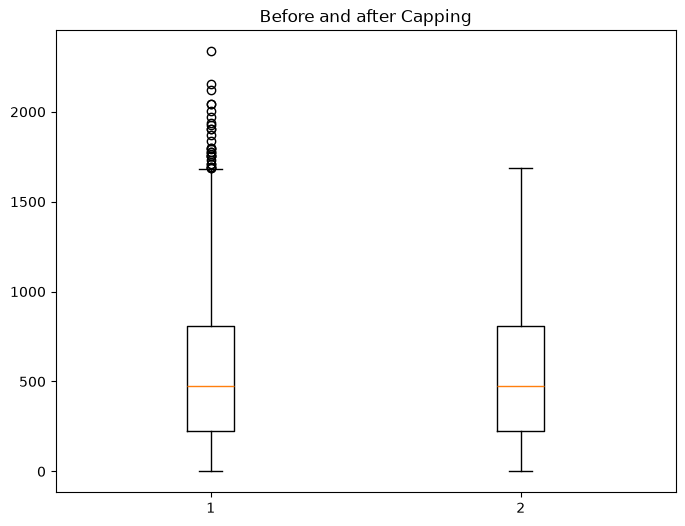

In [58]:
Q1 = dfcopy["BsmtUnfSF"].quantile(0.25)
Q3 = dfcopy["BsmtUnfSF"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["BsmtUnfSF"] = np.where(
    df_capped["BsmtUnfSF"] > upper_limit, upper_limit,
    np.where(df_capped["BsmtUnfSF"] < lower_limit, lower_limit, df_capped["BsmtUnfSF"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["BsmtUnfSF"].dropna(), df_capped["BsmtUnfSF"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

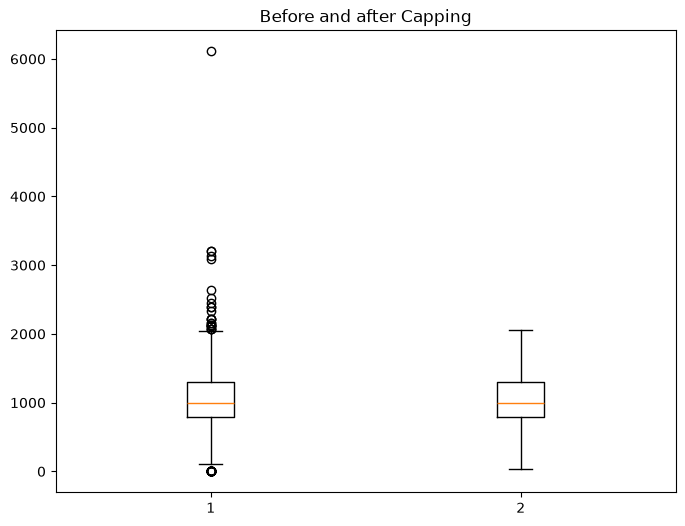

In [59]:
Q1 = dfcopy["TotalBsmtSF"].quantile(0.25)
Q3 = dfcopy["TotalBsmtSF"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["TotalBsmtSF"] = np.where(
    df_capped["TotalBsmtSF"] > upper_limit, upper_limit,
    np.where(df_capped["TotalBsmtSF"] < lower_limit, lower_limit, df_capped["TotalBsmtSF"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["TotalBsmtSF"].dropna(), df_capped["TotalBsmtSF"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

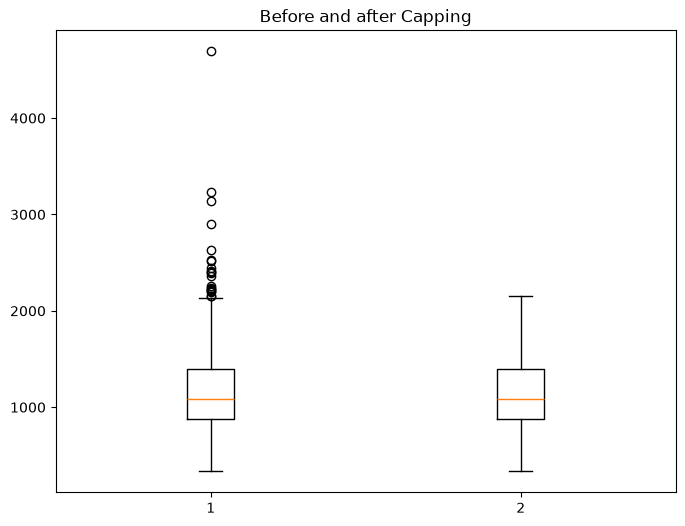

In [60]:
Q1 = dfcopy["1stFlrSF"].quantile(0.25)
Q3 = dfcopy["1stFlrSF"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["1stFlrSF"] = np.where(
    df_capped["1stFlrSF"] > upper_limit, upper_limit,
    np.where(df_capped["1stFlrSF"] < lower_limit, lower_limit, df_capped["1stFlrSF"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["1stFlrSF"].dropna(), df_capped["1stFlrSF"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

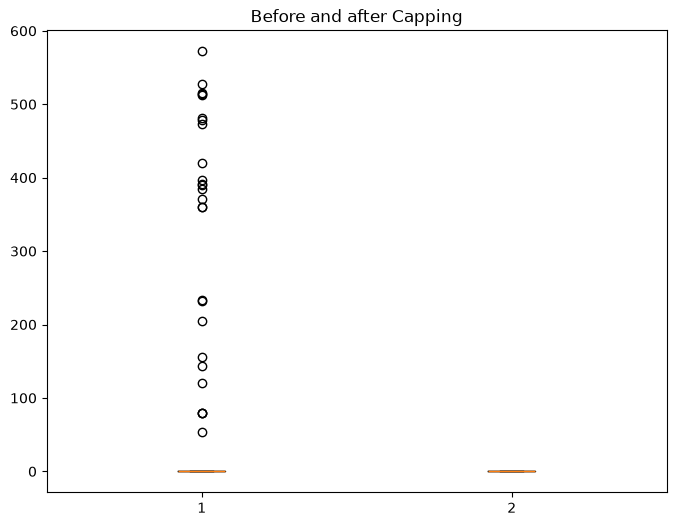

In [61]:
Q1 = dfcopy["LowQualFinSF"].quantile(0.25)
Q3 = dfcopy["LowQualFinSF"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["LowQualFinSF"] = np.where(
    df_capped["LowQualFinSF"] > upper_limit, upper_limit,
    np.where(df_capped["LowQualFinSF"] < lower_limit, lower_limit, df_capped["LowQualFinSF"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["LowQualFinSF"].dropna(), df_capped["LowQualFinSF"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

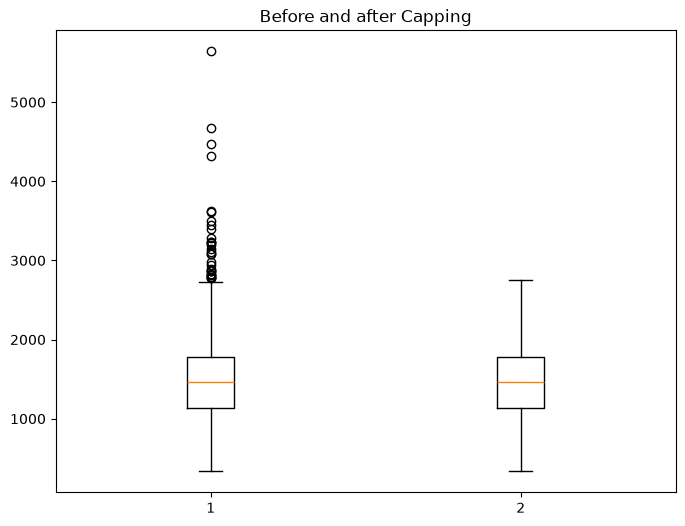

In [62]:
Q1 = dfcopy["GrLivArea"].quantile(0.25)
Q3 = dfcopy["GrLivArea"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_capped = dfcopy.copy()
df_capped["GrLivArea"] = np.where(
    df_capped["GrLivArea"] > upper_limit, upper_limit,
    np.where(df_capped["GrLivArea"] < lower_limit, lower_limit, df_capped["GrLivArea"])
)

plt.figure(figsize=(8,6))

plt.boxplot([dfcopy["GrLivArea"].dropna(), df_capped["GrLivArea"]], 
            label=["Before", "After"])
plt.title("Before and after Capping")
plt.show()

## 2. Encoding for conversion of category to numeric

### a) Label encoding for binary categories
- Street
- Alley
- Utilities
- Central Air

In [101]:
dfcopy["Street"].unique()

<StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

In [102]:
le = LabelEncoder()
dfcopy["Street"] = le.fit_transform(dfcopy["Street"])

dfcopy["Street"].unique()

array([1, 0])

In [119]:
df_dropped = dfcopy.copy()

df_dropped = df_dropped.dropna(subset=["Alley"])

df_dropped["Alley"].unique()

<StringArray>
['Grvl', 'Pave']
Length: 2, dtype: str

In [120]:
df_dropped["Alley"] = le.fit_transform(df_dropped["Alley"])

df_dropped["Alley"].unique()

array([0, 1])

In [121]:
dfcopy["Utilities"].unique()

<StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str

In [122]:
dfcopy["Utilities"] = le.fit_transform(dfcopy["Utilities"])

dfcopy["Utilities"].unique()

array([0, 1])

In [123]:
dfcopy["CentralAir"].unique()

<StringArray>
['Y', 'N']
Length: 2, dtype: str

In [127]:
dfcopy["CentralAir"] = le.fit_transform(dfcopy["CentralAir"])
dfcopy["CentralAir"].unique()

array([1, 0])

### b) One Hot Encoding for columns with multiple categories
- LotShape
- LandContour
- LotConfig
- BldgType
- RoofStyle
- MasVnrType
- ExterQual
- ExterCond
- Foundation
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2
- Heating
- HeatingQC
- Electrical
- KitchenQual
- FireplaceQu
- GarageFinish
- GarageQual
- GarageCond
- Pa
- PoolQC
- Fence
- MiscFeature
- SaleCondition

In [166]:
dfcopy["LotShape"].unique()

<StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str

In [168]:
df_encoded = pd.get_dummies(dfcopy, columns=["LotShape"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LandContour,Utilities,LotConfig,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg
0,1,60,RL,65.0,8450,1,NaN,Lvl,0,Inside,...,0,2,2008,WD,Normal,208500,False,False,False,True
1,2,20,RL,80.0,9600,1,NaN,Lvl,0,FR2,...,0,5,2007,WD,Normal,181500,False,False,False,True
2,3,60,RL,68.0,11250,1,NaN,Lvl,0,Inside,...,0,9,2008,WD,Normal,223500,True,False,False,False
3,4,70,RL,60.0,9550,1,NaN,Lvl,0,Corner,...,0,2,2006,WD,Abnorml,140000,True,False,False,False
4,5,60,RL,84.0,14260,1,NaN,Lvl,0,FR2,...,0,12,2008,WD,Normal,250000,True,False,False,False


In [169]:
df_encoded = pd.get_dummies(dfcopy, columns=["LandContour"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,Utilities,LotConfig,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl
0,1,60,RL,65.0,8450,1,NaN,Reg,0,Inside,...,0,2,2008,WD,Normal,208500,False,False,False,True
1,2,20,RL,80.0,9600,1,NaN,Reg,0,FR2,...,0,5,2007,WD,Normal,181500,False,False,False,True
2,3,60,RL,68.0,11250,1,NaN,IR1,0,Inside,...,0,9,2008,WD,Normal,223500,False,False,False,True
3,4,70,RL,60.0,9550,1,NaN,IR1,0,Corner,...,0,2,2006,WD,Abnorml,140000,False,False,False,True
4,5,60,RL,84.0,14260,1,NaN,IR1,0,FR2,...,0,12,2008,WD,Normal,250000,False,False,False,True


In [170]:
df_encoded = pd.get_dummies(dfcopy, columns=["LotConfig"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside
0,1,60,RL,65.0,8450,1,NaN,Reg,Lvl,0,...,2,2008,WD,Normal,208500,False,False,False,False,True
1,2,20,RL,80.0,9600,1,NaN,Reg,Lvl,0,...,5,2007,WD,Normal,181500,False,False,True,False,False
2,3,60,RL,68.0,11250,1,NaN,IR1,Lvl,0,...,9,2008,WD,Normal,223500,False,False,False,False,True
3,4,70,RL,60.0,9550,1,NaN,IR1,Lvl,0,...,2,2006,WD,Abnorml,140000,True,False,False,False,False
4,5,60,RL,84.0,14260,1,NaN,IR1,Lvl,0,...,12,2008,WD,Normal,250000,False,False,True,False,False


In [171]:
df_encoded = pd.get_dummies(dfcopy, columns=["BldgType"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,1,60,RL,65.0,8450,1,NaN,Reg,Lvl,0,...,2,2008,WD,Normal,208500,True,False,False,False,False
1,2,20,RL,80.0,9600,1,NaN,Reg,Lvl,0,...,5,2007,WD,Normal,181500,True,False,False,False,False
2,3,60,RL,68.0,11250,1,NaN,IR1,Lvl,0,...,9,2008,WD,Normal,223500,True,False,False,False,False
3,4,70,RL,60.0,9550,1,NaN,IR1,Lvl,0,...,2,2006,WD,Abnorml,140000,True,False,False,False,False
4,5,60,RL,84.0,14260,1,NaN,IR1,Lvl,0,...,12,2008,WD,Normal,250000,True,False,False,False,False


In [172]:
df_encoded = pd.get_dummies(dfcopy, columns=["RoofStyle"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,YrSold,SaleType,SaleCondition,SalePrice,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed
0,1,60,RL,65.0,8450,1,NaN,Reg,Lvl,0,...,2008,WD,Normal,208500,False,True,False,False,False,False
1,2,20,RL,80.0,9600,1,NaN,Reg,Lvl,0,...,2007,WD,Normal,181500,False,True,False,False,False,False
2,3,60,RL,68.0,11250,1,NaN,IR1,Lvl,0,...,2008,WD,Normal,223500,False,True,False,False,False,False
3,4,70,RL,60.0,9550,1,NaN,IR1,Lvl,0,...,2006,WD,Abnorml,140000,False,True,False,False,False,False
4,5,60,RL,84.0,14260,1,NaN,IR1,Lvl,0,...,2008,WD,Normal,250000,False,True,False,False,False,False


In [173]:
df_encoded = pd.get_dummies(dfcopy, columns=["MasVnrType"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone
0,1,60,RL,65.0,8450,1,NaN,Reg,Lvl,0,...,NaN,0,2,2008,WD,Normal,208500,False,True,False
1,2,20,RL,80.0,9600,1,NaN,Reg,Lvl,0,...,NaN,0,5,2007,WD,Normal,181500,False,False,False
2,3,60,RL,68.0,11250,1,NaN,IR1,Lvl,0,...,NaN,0,9,2008,WD,Normal,223500,False,True,False
3,4,70,RL,60.0,9550,1,NaN,IR1,Lvl,0,...,NaN,0,2,2006,WD,Abnorml,140000,False,False,False
4,5,60,RL,84.0,14260,1,NaN,IR1,Lvl,0,...,NaN,0,12,2008,WD,Normal,250000,False,True,False


In [174]:
df_encoded = pd.get_dummies(dfcopy, columns=["ExterQual"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA
0,1,60,RL,65.0,8450,1,NaN,Reg,Lvl,0,...,0,2,2008,WD,Normal,208500,False,False,True,False
1,2,20,RL,80.0,9600,1,NaN,Reg,Lvl,0,...,0,5,2007,WD,Normal,181500,False,False,False,True
2,3,60,RL,68.0,11250,1,NaN,IR1,Lvl,0,...,0,9,2008,WD,Normal,223500,False,False,True,False
3,4,70,RL,60.0,9550,1,NaN,IR1,Lvl,0,...,0,2,2006,WD,Abnorml,140000,False,False,False,True
4,5,60,RL,84.0,14260,1,NaN,IR1,Lvl,0,...,0,12,2008,WD,Normal,250000,False,False,True,False


In [175]:
df_encoded = pd.get_dummies(dfcopy, columns=["ExterCond"])
df_encoded.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA
0,1,60,RL,65.0,8450,1,NaN,Reg,Lvl,0,...,2,2008,WD,Normal,208500,False,False,False,False,True
1,2,20,RL,80.0,9600,1,NaN,Reg,Lvl,0,...,5,2007,WD,Normal,181500,False,False,False,False,True
2,3,60,RL,68.0,11250,1,NaN,IR1,Lvl,0,...,9,2008,WD,Normal,223500,False,False,False,False,True
3,4,70,RL,60.0,9550,1,NaN,IR1,Lvl,0,...,2,2006,WD,Abnorml,140000,False,False,False,False,True
4,5,60,RL,84.0,14260,1,NaN,IR1,Lvl,0,...,12,2008,WD,Normal,250000,False,False,False,False,True


### c) Ordinal encoding for testing and practice

- LandSlope
- PavedDrive

In [179]:
dfcopy["LandSlope"].unique()

<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

In [ ]:
encoder = OrdinalEncoder(categories=[['Gtl', 'Mod', 'Sev']])
dfcopy["LandSlope"] = encoder.fit_transform(dfcopy[["LandSlope"]])

dfcopy["LandSlope"].unique()

array([0., 1., 2.])

In [185]:
dfcopy["PavedDrive"].unique()

<StringArray>
['Y', 'N', 'P']
Length: 3, dtype: str

In [8]:
encoder = OrdinalEncoder(categories=[["Y", "N", "P"]])

dfcopy["PavedDrive"] = encoder.fit_transform(dfcopy[["PavedDrive"]])
dfcopy["PavedDrive"].unique()

array([0., 1., 2.])